In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

#Загрузка данных
df = sns.load_dataset('penguins')

Для задачи классификации в датасете пингвинов наиболее естественным целевым классом является атрибут species (вид пингвина)

1. ОЦЕНКА СБАЛАНСИРОВАННОСТИ КЛАССОВ


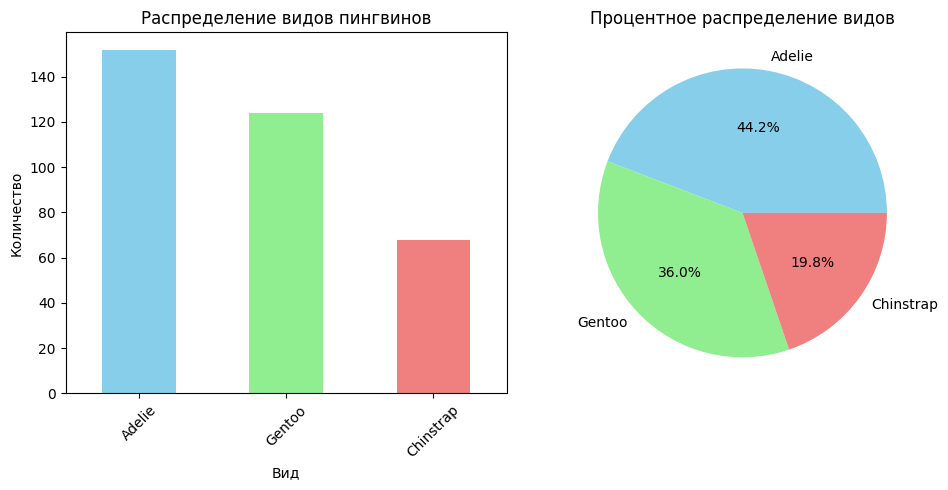


Коэффициент дисбаланса (макс/мин): 2.24
Наблюдается небольшой дисбаланс классов


In [ ]:
print("Для задачи классификации в датасете пингвинов наиболее естественным целевым классом является атрибут species (вид пингвина)")

#Проверяем сбалансированность классов
print("\n1. ОЦЕНКА СБАЛАНСИРОВАННОСТИ КЛАССОВ")

species_distribution = df['species'].value_counts()

#Визуализация распределения классов
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
species_distribution.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Распределение видов пингвинов')
plt.xlabel('Вид')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
species_distribution.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Процентное распределение видов')
plt.ylabel('')

plt.tight_layout()
plt.show()

#Рассчитываем степень дисбаланса
max_count = species_distribution.max()
min_count = species_distribution.min()
imbalance_ratio = max_count / min_count
print(f"\nКоэффициент дисбаланса (макс/мин): {imbalance_ratio:.2f}")
print("Наблюдается небольшой дисбаланс классов")

In [ ]:
print("2. ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ")

print(f"\nПропущенные значения для числовых колонок заполняем медианой")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f"Пропущенные значения для категориальных колонок заполняем модой")
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

#Преобразование категориальных признаков
print("\nПреобразование категориальных признаков:")
df_encoded = pd.get_dummies(df, columns=['island', 'sex'], drop_first=True)

#Определение признаков и целевой переменной
X = df_encoded.drop('species', axis=1)
y = df_encoded['species']

#Кодирование целевой переменной
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#Разделение на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")

#Масштабирование признаков
print("\nМасштабирование признаков:")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

2. ПОДГОТОВКА ДАННЫХ ДЛЯ КЛАССИФИКАЦИИ

Пропущенные значения для числовых колонок заполняем медианой
Пропущенные значения для категориальных колонок заполняем модой

Преобразование категориальных признаков:
Размер обучающей выборки: (240, 7)
Размер тестовой выборки: (104, 7)
Количество признаков: 7

Масштабирование признаков:


3. КЛАССИФИКАЦИЯ С ПОМОЩЬЮ kNN

Подбор оптимального значения k:


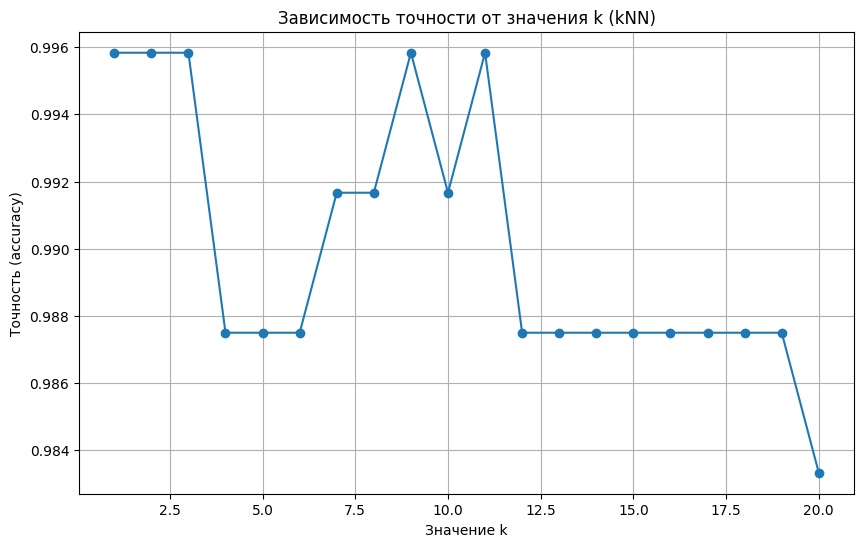

Оптимальное значение k: 1

Оценка модели kNN:
Accuracy: 0.9808


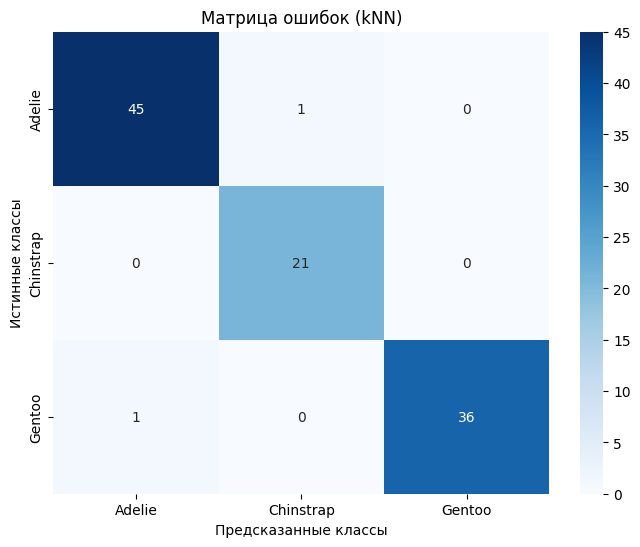

In [ ]:
print("3. КЛАССИФИКАЦИЯ С ПОМОЩЬЮ kNN")

#Подбор оптимального k
print("\nПодбор оптимального значения k:")
k_range = range(1, 21)
accuracy_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    accuracy_scores.append(scores.mean())

#Визуализация зависимости точности от k
plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o')
plt.title('Зависимость точности от значения k (kNN)')
plt.xlabel('Значение k')
plt.ylabel('Точность (accuracy)')
plt.grid(True)
plt.show()

#Выбор оптимального k
optimal_k = k_range[np.argmax(accuracy_scores)]
print(f"Оптимальное значение k: {optimal_k}")

#Обучение модели с оптимальным k
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)

#Предсказание на тестовой выборке
y_pred_knn = knn.predict(X_test_scaled)

#Оценка модели kNN
print("\nОценка модели kNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")

#Матрица ошибок
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок (kNN)')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

4. КЛАССИФИКАЦИЯ С ПОМОЩЬЮ ДЕРЕВА РЕШЕНИЙ

Подбор оптимальных гиперпараметров для дерева решений:
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Лучшая точность при кросс-валидации: 0.9833

Оценка модели дерева решений:
Accuracy: 0.9808


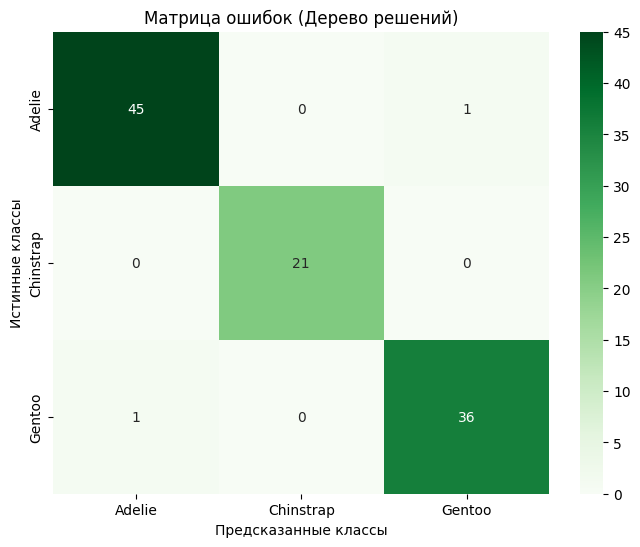


Важность признаков в дереве решений:
             Признак  Важность
2  flipper_length_mm  0.539886
0     bill_length_mm  0.292171
4       island_Dream  0.090229
6           sex_Male  0.048932
3        body_mass_g  0.018473
1      bill_depth_mm  0.010310
5   island_Torgersen  0.000000


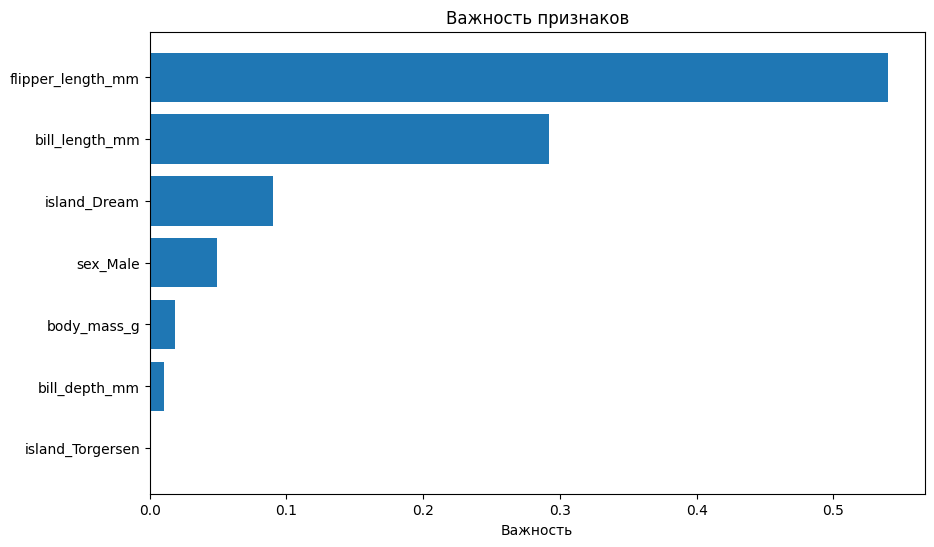

In [ ]:
print("4. КЛАССИФИКАЦИЯ С ПОМОЩЬЮ ДЕРЕВА РЕШЕНИЙ")


print("\nПодбор оптимальных гиперпараметров для дерева решений:")
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")

#Обучение модели с оптимальными параметрами
dt_best = grid_search.best_estimator_
dt_best.fit(X_train_scaled, y_train)

#Предсказание на тестовой выборке
y_pred_dt = dt_best.predict(X_test_scaled)

#Оценка модели дерева решений
print("\nОценка модели дерева решений:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")

#Матрица ошибок
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Матрица ошибок (Дерево решений)')
plt.ylabel('Истинные классы')
plt.xlabel('Предсказанные классы')
plt.show()

#Важность признаков
feature_importance = pd.DataFrame({
    'Признак': X.columns,
    'Важность': dt_best.feature_importances_
}).sort_values('Важность', ascending=False)

print("\nВажность признаков в дереве решений:")
print(feature_importance.head(10))

#Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Признак'][:10], feature_importance['Важность'][:10])
plt.title('Важность признаков')
plt.xlabel('Важность')
plt.gca().invert_yaxis()
plt.show()

5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ
     Метрика       kNN  Дерево решений
0   Accuracy  0.980769        0.980769
1  Precision  0.981206        0.980769
2     Recall  0.980769        0.980769
3   F1-Score  0.980815        0.980769

Построение ROC-кривых для многоклассовой классификации...


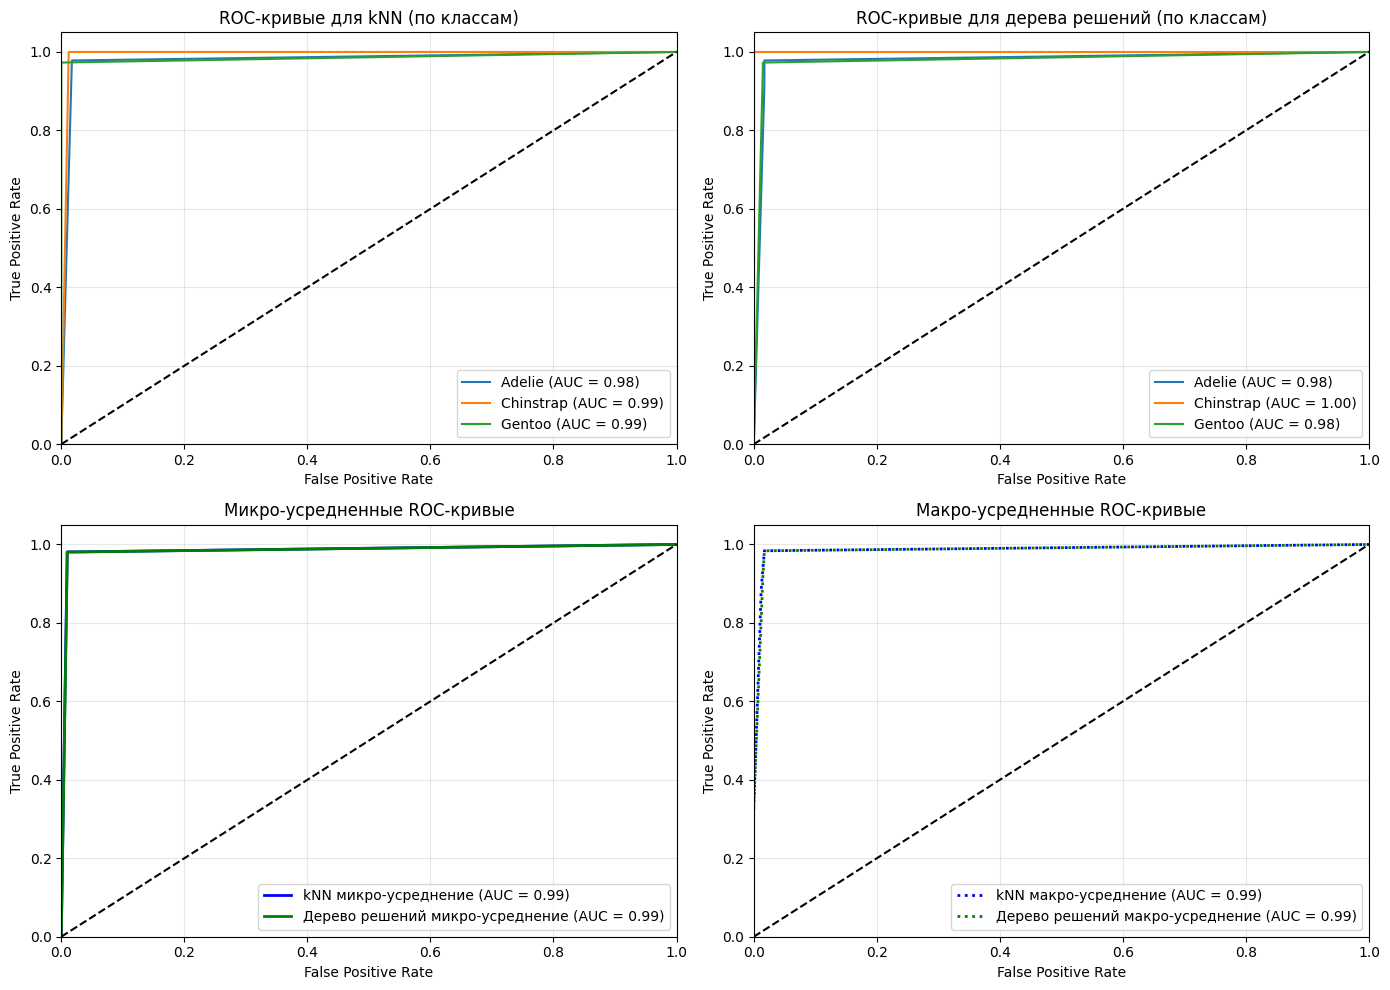


AUC метрики (микро-усреднение):
  kNN: 0.9856
  Дерево решений: 0.9853

AUC метрики (макро-усреднение):
  kNN: 0.9870
  Дерево решений: 0.9863


In [ ]:
print("5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ")

metrics_knn = precision_recall_fscore_support(y_test, y_pred_knn, average='weighted')
metrics_dt = precision_recall_fscore_support(y_test, y_pred_dt, average='weighted')

comparison_df = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'kNN': [
        accuracy_score(y_test, y_pred_knn),
        metrics_knn[0],
        metrics_knn[1],
        metrics_knn[2]
    ],
    'Дерево решений': [
        accuracy_score(y_test, y_pred_dt),
        metrics_dt[0],
        metrics_dt[1],
        metrics_dt[2]
    ]
})

print(comparison_df)

#ROC-кривые для многоклассовой классификации
print("\nПостроение ROC-кривых для многоклассовой классификации...")

#Бинаризация целевых переменных для ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

#Получение вероятностей для каждого класса
y_prob_knn = knn.predict_proba(X_test_scaled)
y_prob_dt = dt_best.predict_proba(X_test_scaled)

#Вычисление ROC кривых и AUC для каждой модели и каждого класса
plt.figure(figsize=(14, 10))

#kNN ROC кривые
plt.subplot(2, 2, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для kNN (по классам)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

#Дерево решений ROC кривые
plt.subplot(2, 2, 2)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для дерева решений (по классам)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

#Микро-усредненные ROC кривые
plt.subplot(2, 2, 3)
#kNN микро-усреднение
fpr_micro_knn, tpr_micro_knn, _ = roc_curve(y_test_bin.ravel(), y_prob_knn.ravel())
roc_auc_micro_knn = auc(fpr_micro_knn, tpr_micro_knn)
plt.plot(fpr_micro_knn, tpr_micro_knn, label=f'kNN микро-усреднение (AUC = {roc_auc_micro_knn:.2f})', color='blue', linewidth=2)

#Дерево решений микро-усреднение
fpr_micro_dt, tpr_micro_dt, _ = roc_curve(y_test_bin.ravel(), y_prob_dt.ravel())
roc_auc_micro_dt = auc(fpr_micro_dt, tpr_micro_dt)
plt.plot(fpr_micro_dt, tpr_micro_dt, label=f'Дерево решений микро-усреднение (AUC = {roc_auc_micro_dt:.2f})', color='green', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Микро-усредненные ROC-кривые')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

#Макро-усредненные ROC кривые
plt.subplot(2, 2, 4)
#kNN макро-усреднение
all_fpr_knn = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_knn[:, i])[0] for i in range(n_classes)]))
mean_tpr_knn = np.zeros_like(all_fpr_knn)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    mean_tpr_knn += np.interp(all_fpr_knn, fpr, tpr)
mean_tpr_knn /= n_classes
roc_auc_macro_knn = auc(all_fpr_knn, mean_tpr_knn)
plt.plot(all_fpr_knn, mean_tpr_knn, label=f'kNN макро-усреднение (AUC = {roc_auc_macro_knn:.2f})', color='blue', linestyle=':', linewidth=2)

#Дерево решений макро-усреднение
all_fpr_dt = np.unique(np.concatenate([roc_curve(y_test_bin[:, i], y_prob_dt[:, i])[0] for i in range(n_classes)]))
mean_tpr_dt = np.zeros_like(all_fpr_dt)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    mean_tpr_dt += np.interp(all_fpr_dt, fpr, tpr)
mean_tpr_dt /= n_classes
roc_auc_macro_dt = auc(all_fpr_dt, mean_tpr_dt)
plt.plot(all_fpr_dt, mean_tpr_dt, label=f'Дерево решений макро-усреднение (AUC = {roc_auc_macro_dt:.2f})', color='green', linestyle=':', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Макро-усредненные ROC-кривые')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAUC метрики (микро-усреднение):")
print(f"  kNN: {roc_auc_micro_knn:.4f}")
print(f"  Дерево решений: {roc_auc_micro_dt:.4f}")

print(f"\nAUC метрики (макро-усреднение):")
print(f"  kNN: {roc_auc_macro_knn:.4f}")
print(f"  Дерево решений: {roc_auc_macro_dt:.4f}")

In [ ]:
print("\n3. ВЫВОДЫ")

print("\nОба алгоритма показали высокую точность (>95%) при определении видов пингвинов")
print("kNN и дерево решений достигли почти одинаковых результатов (разница <1%)")
print("Это происходит, так как признаки образуют явные кластеры и обе модели хорошо их распознают\n")

print("kNN: проще в настройке, но требует масштабирования данных и выбора оптимального k")
print("Дерево решений: предоставляет интерпретируемые правила, выявляет важные признаки\n")

print("Ключевой вывод:")
print("Физические характеристики пингвинов являются высокоинформативными признаками для классификации видов,")
print("что позволяет достигать точности >95% даже с простыми алгоритмами.")


3. ВЫВОДЫ

Оба алгоритма показали высокую точность (>95%) при определении видов пингвинов
kNN и дерево решений достигли почти одинаковых результатов (разница <1%)
Это происходит, так как признаки образуют явные кластеры и обе модели хорошо их распознают

kNN: проще в настройке, но требует масштабирования данных и выбора оптимального k
Дерево решений: предоставляет интерпретируемые правила, выявляет важные признаки

Ключевой вывод:
Физические характеристики пингвинов являются высокоинформативными признаками для классификации видов,
что позволяет достигать точности >95% даже с простыми алгоритмами.


![image.png](https://camo.githubusercontent.com/da3f10f73e6f6c1d96a76d1872f77a393aa373c89eb44bd6c2bc530df792c40a/687474703a2f2f643369336c336b7261697170796d2e636c6f756466726f6e742e6e65742f77702d636f6e74656e742f75706c6f6164732f323031362f30342f32363039343931342f41642543332541396c69652d4368696e73747261702d616e642d67656e746f6f2d70656e6775696e2d737065636965732e6a7067)